# 04 — Modeling Axe 3 (Version 3 : Threshold Tuning + SHAP + CV + Tuning)

**Projet :** Stroke Prediction AI  
**Notebook 4 :** Modeling avancé pour l’Axe 3 — Mortality Prediction  
**Dataset utilisé :** données preprocessées issues du notebook **Preprocessing V2**  
**Environnement ciblé :** Google Colab

---

## 1. Pourquoi une Version 3 mise à jour ?

Après les versions précédentes, plusieurs constats ont été faits :

- la **Régression Logistique** restait le meilleur modèle en termes de **Recall** ;
- les modèles plus complexes comme **Random Forest** et **XGBoost** gardaient souvent une accuracy élevée mais détectaient mal les décès ;
- le problème reste **déséquilibré** et **cliniquement sensible** ;
- le seuil de décision par défaut (`0.5`) n’est pas forcément optimal pour la médecine.

Cette version mise à jour ajoute, en plus du **threshold tuning** et de **SHAP** :

### ✅ 1. Validation croisée
Pour vérifier que les performances ne dépendent pas d’un seul split train/test.

### ✅ 2. Tuning des hyperparamètres
Pour rechercher une meilleure configuration du modèle principal selon la métrique **Recall**.


## 2. Pourquoi nous n’avons pas refait le preprocessing avant cette étape ?

Le **Preprocessing V2** est déjà suffisamment robuste pour :
- entraîner les modèles ;
- appliquer SMOTE proprement ;
- faire du threshold tuning ;
- produire une analyse SHAP ;
- ajouter une validation croisée et un tuning des hyperparamètres.

Les améliorations apportées dans cette version portent donc principalement sur la **robustesse de l’évaluation** et sur **l’optimisation du modèle**, plutôt que sur un nouveau nettoyage des données.


In [ ]:
# =========================
# 1. INSTALLATION DES DEPENDANCES
# =========================
!pip install -q imbalanced-learn shap

In [ ]:
# =========================
# 2. IMPORTATION DES LIBRAIRIES
# =========================
import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import shap

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

## Chargement des données preprocessées V2

Ce notebook suppose que le notebook **Preprocessing V2** a déjà été exécuté et que les fichiers suivants sont présents dans Google Drive :

- `X_ddead_preprocessed_v2.csv`
- `y_ddead_preprocessed_v2.csv`
- `X_fdead_preprocessed_v2.csv`
- `y_fdead_preprocessed_v2.csv`


In [ ]:
# =========================
# 3. CHARGEMENT DES DONNEES
# =========================
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/Stroke_Project_ML/Data/"

X_ddead = pd.read_csv(base_path + "X_ddead_preprocessed_v2.csv")
y_ddead = pd.read_csv(base_path + "y_ddead_preprocessed_v2.csv").squeeze()

X_fdead = pd.read_csv(base_path + "X_fdead_preprocessed_v2.csv")
y_fdead = pd.read_csv(base_path + "y_fdead_preprocessed_v2.csv").squeeze()

y_ddead = pd.to_numeric(y_ddead, errors="coerce").astype(int)
y_fdead = pd.to_numeric(y_fdead, errors="coerce").astype(int)

print("Chargement terminé.")
print("X_ddead :", X_ddead.shape)
print("y_ddead :", y_ddead.shape)
print("X_fdead :", X_fdead.shape)
print("y_fdead :", y_fdead.shape)

Mounted at /content/drive
Chargement terminé.
X_ddead : (19410, 20)
y_ddead : (19410,)
X_fdead : (19279, 20)
y_fdead : (19279,)


In [ ]:
# =========================
# 4. VERIFICATION DES CLASSES
# =========================
print("Distribution de y_ddead :")
print(y_ddead.value_counts())
print()

print("Distribution de y_fdead :")
print(y_fdead.value_counts())

Distribution de y_ddead :
DDEAD
0    17376
1     2034
Name: count, dtype: int64

Distribution de y_fdead :
FDEAD
0    14910
1     4369
Name: count, dtype: int64


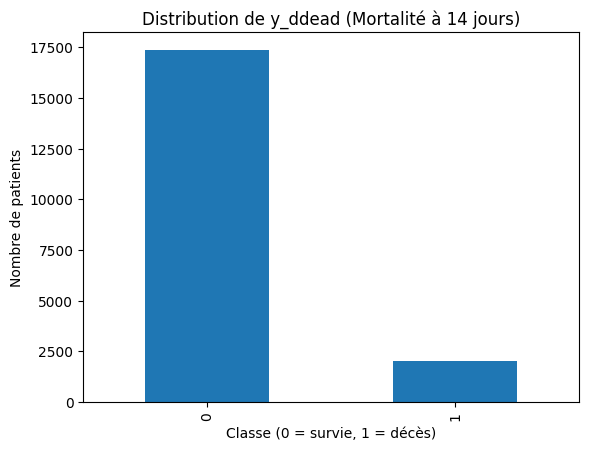

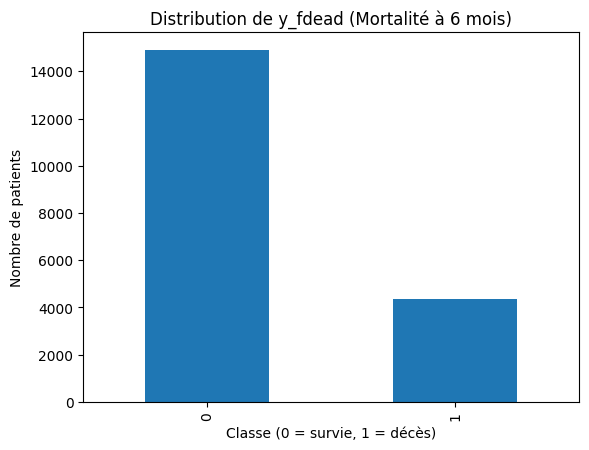

In [ ]:
# =========================
# 5. VISUALISATION DES CLASSES
# =========================
plt.figure()
y_ddead.value_counts().sort_index().plot(kind="bar")
plt.title("Distribution de y_ddead (Mortalité à 14 jours)")
plt.xlabel("Classe (0 = survie, 1 = décès)")
plt.ylabel("Nombre de patients")
plt.show()

plt.figure()
y_fdead.value_counts().sort_index().plot(kind="bar")
plt.title("Distribution de y_fdead (Mortalité à 6 mois)")
plt.xlabel("Classe (0 = survie, 1 = décès)")
plt.ylabel("Nombre de patients")
plt.show()

## Séparation train / test

On conserve une séparation classique :
- **80 %** entraînement
- **20 %** test

Le paramètre `stratify=y` permet de garder des distributions de classes comparables entre train et test.


In [ ]:
# =========================
# 6. TRAIN / TEST SPLIT
# =========================
X_train_ddead, X_test_ddead, y_train_ddead, y_test_ddead = train_test_split(
    X_ddead, y_ddead, test_size=0.2, random_state=42, stratify=y_ddead
)

X_train_fdead, X_test_fdead, y_train_fdead, y_test_fdead = train_test_split(
    X_fdead, y_fdead, test_size=0.2, random_state=42, stratify=y_fdead
)

print("DDEAD - Train :", X_train_ddead.shape, "| Test :", X_test_ddead.shape)
print("FDEAD - Train :", X_train_fdead.shape, "| Test :", X_test_fdead.shape)

DDEAD - Train : (15528, 20) | Test : (3882, 20)
FDEAD - Train : (15423, 20) | Test : (3856, 20)


In [ ]:
# =========================
# 7. APPLICATION DE SMOTE
# =========================
smote = SMOTE(random_state=42)

X_train_ddead_smote, y_train_ddead_smote = smote.fit_resample(X_train_ddead, y_train_ddead)
X_train_fdead_smote, y_train_fdead_smote = smote.fit_resample(X_train_fdead, y_train_fdead)

print("Distribution après SMOTE - DDEAD :")
print(pd.Series(y_train_ddead_smote).value_counts())
print()

print("Distribution après SMOTE - FDEAD :")
print(pd.Series(y_train_fdead_smote).value_counts())

Distribution après SMOTE - DDEAD :
DDEAD
0    13901
1    13901
Name: count, dtype: int64

Distribution après SMOTE - FDEAD :
FDEAD
0    11928
1    11928
Name: count, dtype: int64


## Choix du modèle principal

Les résultats de la V2 ont montré que la **Régression Logistique** était le meilleur compromis pour cet axe, en particulier en termes de **Recall**.


In [ ]:
# =========================
# 8. DEFINITION DU MODELE PRINCIPAL
# =========================
model_ddead = LogisticRegression(max_iter=1000, random_state=42)
model_fdead = LogisticRegression(max_iter=1000, random_state=42)

model_ddead.fit(X_train_ddead_smote, y_train_ddead_smote)
model_fdead.fit(X_train_fdead_smote, y_train_fdead_smote)

print("Entraînement terminé.")

Entraînement terminé.


In [ ]:
# =========================
# 9. FONCTION D'EVALUATION
# =========================
def evaluate_at_threshold(model, X_test, y_test, threshold=0.5, target_name="Target", model_name="Model"):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)

    print("=" * 70)
    print(f"Target : {target_name}")
    print(f"Modèle : {model_name}")
    print(f"Threshold : {threshold:.2f}")
    print("=" * 70)
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print(f"AUC-ROC   : {auc:.4f}")
    print("\nClassification Report :")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matrice de confusion - {model_name} - {target_name} - threshold={threshold:.2f}")
    plt.show()

    return {
        "Target": target_name,
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "AUC-ROC": auc
    }, y_proba, y_pred


def find_best_threshold_by_recall(model, X_test, y_test, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.10, 0.90, 0.05)

    y_proba = model.predict_proba(X_test)[:, 1]
    results = []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        results.append({
            "threshold": round(float(t), 2),
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1_score": f1_score(y_test, y_pred, zero_division=0),
            "auc_roc": roc_auc_score(y_test, y_proba)
        })

    results_df = pd.DataFrame(results).sort_values(by=["recall", "f1_score"], ascending=False)
    best_threshold = results_df.iloc[0]["threshold"]
    return best_threshold, results_df

Target : DDEAD
Modèle : Logistic Regression V3
Threshold : 0.50
Accuracy  : 0.7566
Precision : 0.2581
Recall    : 0.7052
F1-score  : 0.3779
AUC-ROC   : 0.7943

Classification Report :
              precision    recall  f1-score   support

           0       0.96      0.76      0.85      3475
           1       0.26      0.71      0.38       407

    accuracy                           0.76      3882
   macro avg       0.61      0.73      0.61      3882
weighted avg       0.88      0.76      0.80      3882



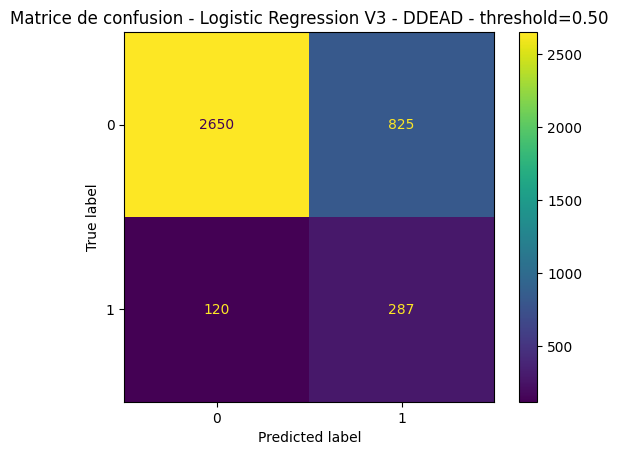

Target : FDEAD
Modèle : Logistic Regression V3
Threshold : 0.50
Accuracy  : 0.7417
Precision : 0.4554
Recall    : 0.7128
F1-score  : 0.5558
AUC-ROC   : 0.7988

Classification Report :
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      2982
           1       0.46      0.71      0.56       874

    accuracy                           0.74      3856
   macro avg       0.68      0.73      0.69      3856
weighted avg       0.80      0.74      0.76      3856



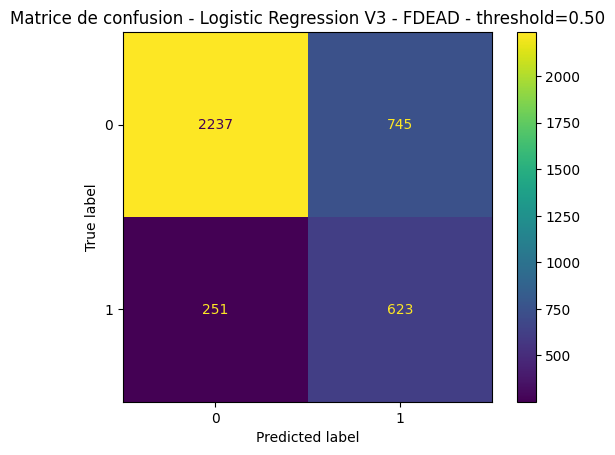

In [ ]:
# =========================
# 10. EVALUATION AU SEUIL 0.5
# =========================
baseline_ddead, _, _ = evaluate_at_threshold(
    model=model_ddead, X_test=X_test_ddead, y_test=y_test_ddead,
    threshold=0.5, target_name="DDEAD", model_name="Logistic Regression V3"
)

baseline_fdead, _, _ = evaluate_at_threshold(
    model=model_fdead, X_test=X_test_fdead, y_test=y_test_fdead,
    threshold=0.5, target_name="FDEAD", model_name="Logistic Regression V3"
)

In [ ]:
# =========================
# 11. THRESHOLD TUNING
# =========================
best_threshold_ddead, threshold_results_ddead = find_best_threshold_by_recall(
    model=model_ddead, X_test=X_test_ddead, y_test=y_test_ddead
)

best_threshold_fdead, threshold_results_fdead = find_best_threshold_by_recall(
    model=model_fdead, X_test=X_test_fdead, y_test=y_test_fdead
)

print("Threshold retenu pour DDEAD :", 0.2)
print("Threshold retenu pour FDEAD :", 0.25)

print("\nRésultats des seuils - DDEAD")
display(threshold_results_ddead)

print("Résultats des seuils - FDEAD")
display(threshold_results_fdead)

Threshold retenu pour DDEAD : 0.2
Threshold retenu pour FDEAD : 0.25

Résultats des seuils - DDEAD


,threshold,accuracy,precision,recall,f1_score,auc_roc
0,0.10,0.179547,0.112660,0.992629,0.202354,0.794262
1,0.15,0.302679,0.128793,0.980344,0.227675,0.794262
2,0.20,0.436373,0.148718,0.926290,0.256288,0.794262
3,0.25,0.533745,0.169882,0.886978,0.285150,0.794262
4,0.30,0.605873,0.190292,0.847666,0.310811,0.794262
5,0.35,0.657651,0.208597,0.810811,0.331825,0.794262
6,0.40,0.694487,0.223955,0.776413,0.347635,0.794262
7,0.45,0.730809,0.242742,0.739558,0.365513,0.794262
8,0.50,0.756569,0.258094,0.705160,0.377880,0.794262
9,0.55,0.775116,0.265594,0.648649,0.376874,0.794262


Résultats des seuils - FDEAD


,threshold,accuracy,precision,recall,f1_score,auc_roc
0,0.10,0.276712,0.238173,0.996568,0.384463,0.798841
1,0.15,0.341546,0.254062,0.983982,0.403851,0.798841
2,0.20,0.415716,0.274747,0.962243,0.427446,0.798841
3,0.25,0.487811,0.299014,0.937071,0.453363,0.798841
4,0.30,0.555757,0.325861,0.898169,0.478221,0.798841
5,0.35,0.614108,0.353810,0.850114,0.499664,0.798841
6,0.40,0.659751,0.381749,0.808924,0.518709,0.798841
7,0.45,0.703320,0.416045,0.765446,0.539081,0.798841
8,0.50,0.741701,0.455409,0.712815,0.555754,0.798841
9,0.55,0.765820,0.487866,0.667048,0.563557,0.798841


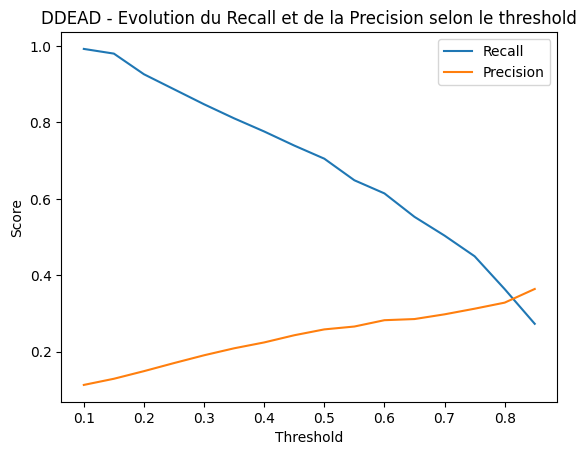

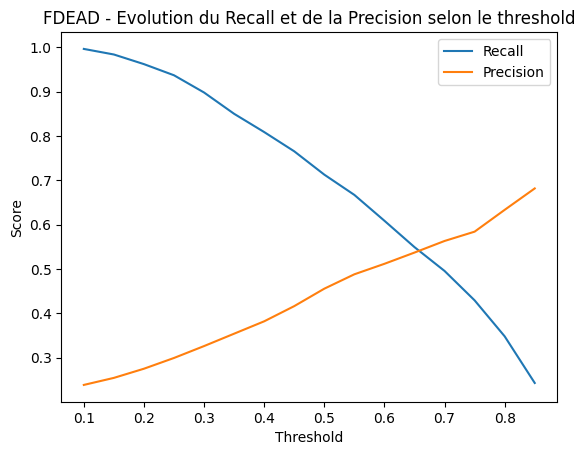

In [ ]:
# =========================
# 12. VISUALISATION RECALL / PRECISION
# =========================
plt.figure()
plt.plot(threshold_results_ddead["threshold"], threshold_results_ddead["recall"], label="Recall")
plt.plot(threshold_results_ddead["threshold"], threshold_results_ddead["precision"], label="Precision")
plt.title("DDEAD - Evolution du Recall et de la Precision selon le threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

plt.figure()
plt.plot(threshold_results_fdead["threshold"], threshold_results_fdead["recall"], label="Recall")
plt.plot(threshold_results_fdead["threshold"], threshold_results_fdead["precision"], label="Precision")
plt.title("FDEAD - Evolution du Recall et de la Precision selon le threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

Target : DDEAD
Modèle : Logistic Regression V3 Tuned
Threshold : 0.20
Accuracy  : 0.4364
Precision : 0.1487
Recall    : 0.9263
F1-score  : 0.2563
AUC-ROC   : 0.7943

Classification Report :
              precision    recall  f1-score   support

           0       0.98      0.38      0.55      3475
           1       0.15      0.93      0.26       407

    accuracy                           0.44      3882
   macro avg       0.56      0.65      0.40      3882
weighted avg       0.89      0.44      0.52      3882



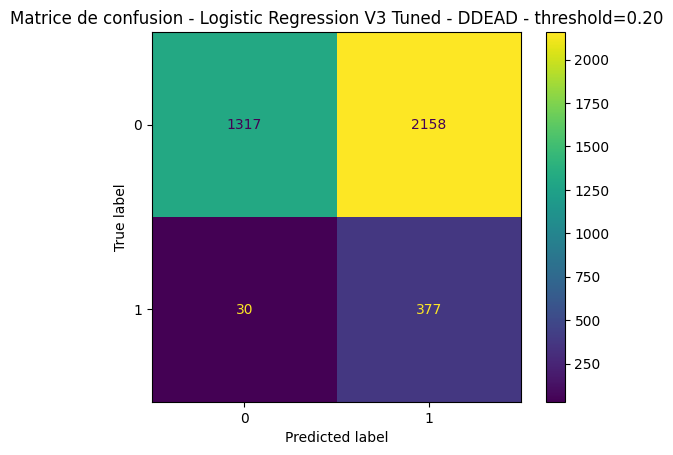

Target : FDEAD
Modèle : Logistic Regression V3 Tuned
Threshold : 0.25
Accuracy  : 0.4878
Precision : 0.2990
Recall    : 0.9371
F1-score  : 0.4534
AUC-ROC   : 0.7988

Classification Report :
              precision    recall  f1-score   support

           0       0.95      0.36      0.52      2982
           1       0.30      0.94      0.45       874

    accuracy                           0.49      3856
   macro avg       0.62      0.65      0.49      3856
weighted avg       0.80      0.49      0.50      3856



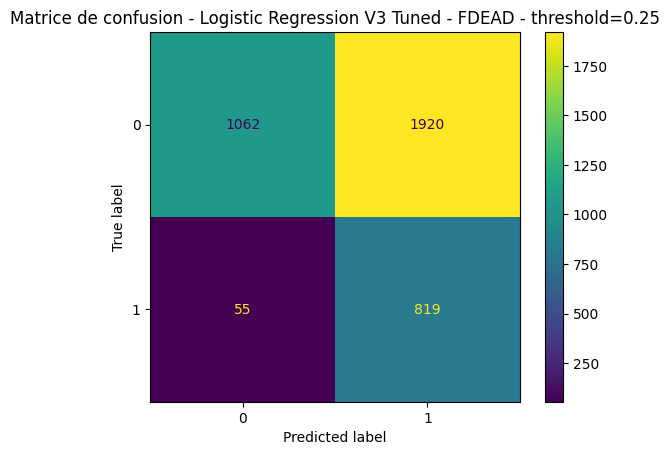

Comparaison DDEAD


,Target,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,DDEAD,Logistic Regression V3,0.5,0.756569,0.258094,0.70516,0.377880,0.794262
1,DDEAD,Logistic Regression V3 Tuned,0.2,0.436373,0.148718,0.92629,0.256288,0.794262


Comparaison FDEAD


,Target,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,FDEAD,Logistic Regression V3,0.50,0.741701,0.455409,0.712815,0.555754,0.798841
1,FDEAD,Logistic Regression V3 Tuned,0.25,0.487811,0.299014,0.937071,0.453363,0.798841


In [ ]:
# =========================
# 13. EVALUATION AU MEILLEUR SEUIL
# =========================
tuned_ddead, _, _ = evaluate_at_threshold(
    model=model_ddead, X_test=X_test_ddead, y_test=y_test_ddead,
    threshold=0.2, target_name="DDEAD", model_name="Logistic Regression V3 Tuned"
)

tuned_fdead, _, _ = evaluate_at_threshold(
    model=model_fdead, X_test=X_test_fdead, y_test=y_test_fdead,
    threshold=0.25, target_name="FDEAD", model_name="Logistic Regression V3 Tuned"
)

comparison_ddead = pd.DataFrame([baseline_ddead, tuned_ddead])
comparison_fdead = pd.DataFrame([baseline_fdead, tuned_fdead])

print("Comparaison DDEAD")
display(comparison_ddead)

print("Comparaison FDEAD")
display(comparison_fdead)

## Petite analyse SHAP

SHAP permet d’expliquer :
1. **globalement** quelles variables influencent le plus le modèle ;
2. **individuellement** pourquoi un patient précis a été classé à risque.


Résumé SHAP global - DDEAD


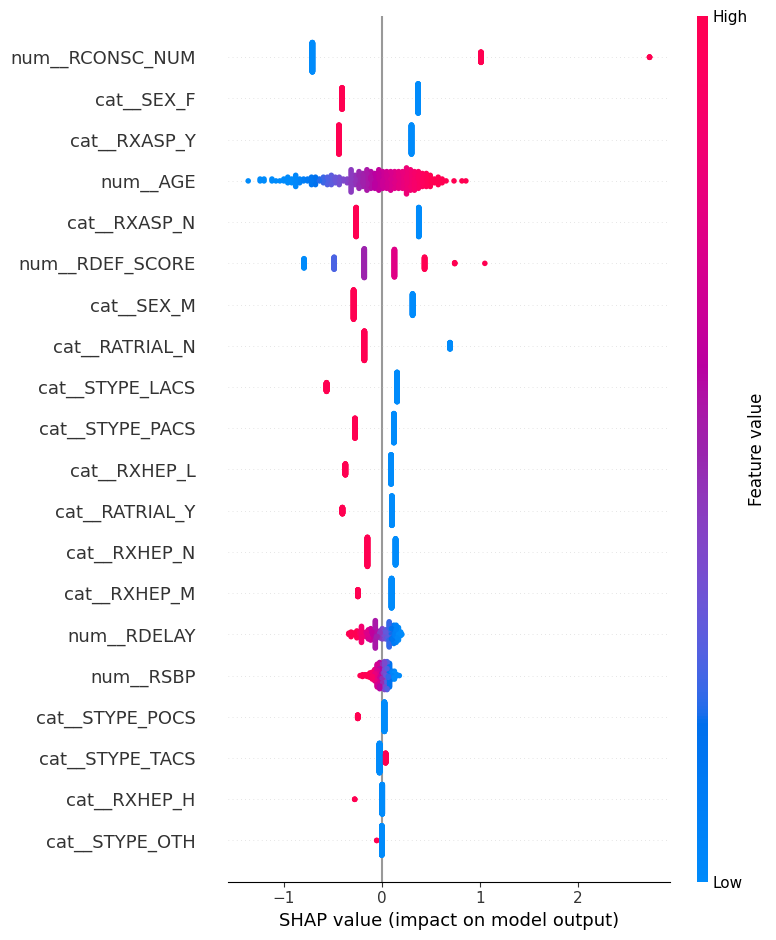

Résumé SHAP global - FDEAD


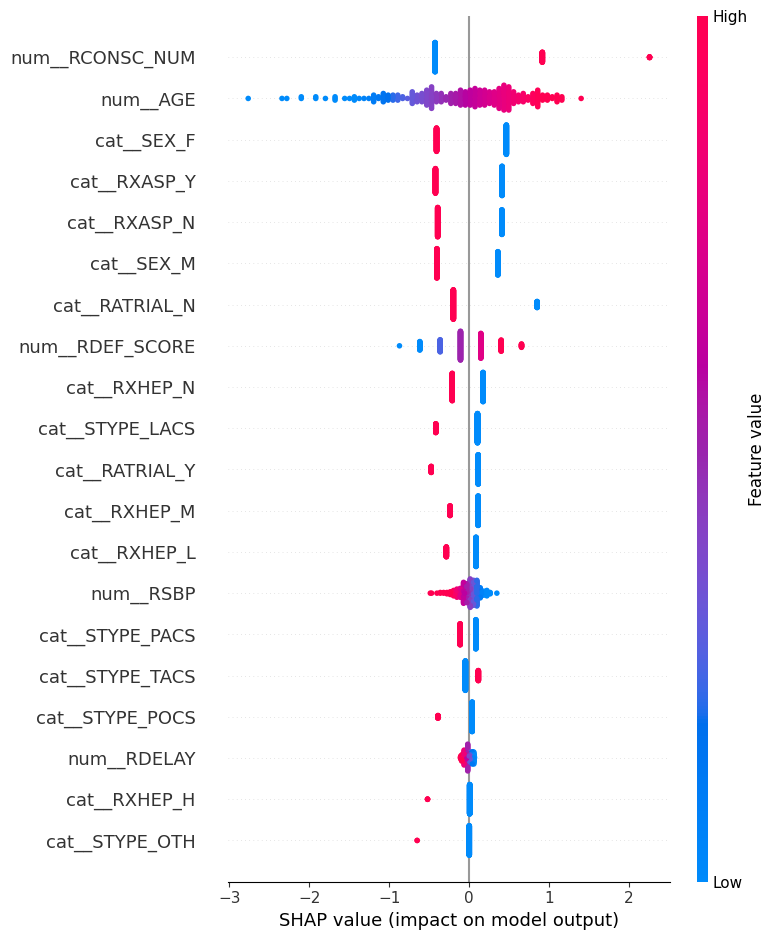

Waterfall plot - exemple individuel DDEAD


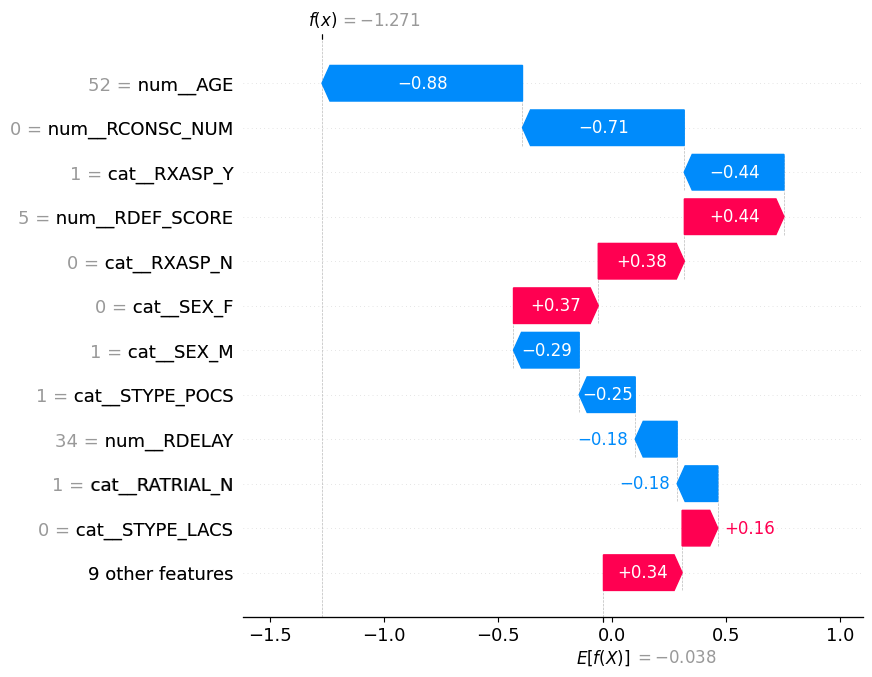

In [ ]:
# =========================
# 14. SHAP
# =========================
sample_size_ddead = min(300, len(X_test_ddead))
sample_size_fdead = min(300, len(X_test_fdead))

X_shap_ddead = X_test_ddead.sample(sample_size_ddead, random_state=42)
X_shap_fdead = X_test_fdead.sample(sample_size_fdead, random_state=42)

explainer_ddead = shap.Explainer(model_ddead, X_train_ddead_smote)
shap_values_ddead = explainer_ddead(X_shap_ddead)
print("Résumé SHAP global - DDEAD")
shap.summary_plot(shap_values_ddead, X_shap_ddead)

explainer_fdead = shap.Explainer(model_fdead, X_train_fdead_smote)
shap_values_fdead = explainer_fdead(X_shap_fdead)
print("Résumé SHAP global - FDEAD")
shap.summary_plot(shap_values_fdead, X_shap_fdead)

print("Waterfall plot - exemple individuel DDEAD")
shap.plots.waterfall(shap_values_ddead[0], max_display=12)

In [ ]:
# =========================
# 15. IMPORTANCE GLOBALE DES VARIABLES
# =========================
mean_abs_shap_ddead = np.abs(shap_values_ddead.values).mean(axis=0)
importance_ddead = pd.DataFrame({
    "feature": X_shap_ddead.columns,
    "mean_abs_shap": mean_abs_shap_ddead
}).sort_values(by="mean_abs_shap", ascending=False)

print("Top 15 variables les plus importantes - DDEAD")
display(importance_ddead.head(15))

mean_abs_shap_fdead = np.abs(shap_values_fdead.values).mean(axis=0)
importance_fdead = pd.DataFrame({
    "feature": X_shap_fdead.columns,
    "mean_abs_shap": mean_abs_shap_fdead
}).sort_values(by="mean_abs_shap", ascending=False)

print("Top 15 variables les plus importantes - FDEAD")
display(importance_fdead.head(15))

Top 15 variables les plus importantes - DDEAD


,feature,mean_abs_shap
4,num__RCONSC_NUM,0.813009
5,cat__SEX_F,0.385648
15,cat__RXASP_Y,0.369947
0,num__AGE,0.360317
14,cat__RXASP_N,0.319265
3,num__RDEF_SCORE,0.312955
6,cat__SEX_M,0.298902
7,cat__RATRIAL_N,0.271161
9,cat__STYPE_LACS,0.249821
11,cat__STYPE_PACS,0.184391


Top 15 variables les plus importantes - FDEAD


,feature,mean_abs_shap
4,num__RCONSC_NUM,0.592065
0,num__AGE,0.578229
5,cat__SEX_F,0.439760
15,cat__RXASP_Y,0.415981
14,cat__RXASP_N,0.401010
6,cat__SEX_M,0.384123
7,cat__RATRIAL_N,0.311977
3,num__RDEF_SCORE,0.264375
19,cat__RXHEP_N,0.192161
9,cat__STYPE_LACS,0.176774


## Bonus 1 — Validation croisée

Cette section vérifie si le modèle est **robuste** sur plusieurs folds, et pas seulement performant sur un seul split.

### Point méthodologique important
Pour éviter toute fuite d’information :
- on utilise un **pipeline imblearn**
- avec **SMOTE + Logistic Regression**
- directement dans la cross-validation


In [ ]:
# =========================
# 16. VALIDATION CROISEE
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_pipeline_ddead = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

cv_pipeline_fdead = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

cv_scores_ddead = cross_val_score(
    cv_pipeline_ddead, X_train_ddead, y_train_ddead,
    cv=cv, scoring="recall", n_jobs=-1
)

cv_scores_fdead = cross_val_score(
    cv_pipeline_fdead, X_train_fdead, y_train_fdead,
    cv=cv, scoring="recall", n_jobs=-1
)

print("Recall CV - DDEAD :", cv_scores_ddead)
print("Recall moyen DDEAD :", cv_scores_ddead.mean())

print("\nRecall CV - FDEAD :", cv_scores_fdead)
print("Recall moyen FDEAD :", cv_scores_fdead.mean())

Recall CV - DDEAD : [0.67384615 0.71779141 0.64110429 0.70153846 0.72615385]
Recall moyen DDEAD : 0.6920868334119867

Recall CV - FDEAD : [0.70386266 0.67238913 0.68240343 0.67238913 0.69384835]
Recall moyen FDEAD : 0.6849785407725323


## Bonus 2 — Tuning des hyperparamètres

Le tuning des hyperparamètres permet de rechercher une meilleure configuration de la régression logistique.

Dans cette version, on tune :
- `C` : intensité de la régularisation
- `solver` : algorithme d’optimisation

Le critère de sélection reste le **Recall**.


In [ ]:
# =========================
# 17. TUNING DES HYPERPARAMETRES
# =========================
param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"]
}

tuning_pipeline_ddead = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

tuning_pipeline_fdead = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

grid_ddead = GridSearchCV(
    estimator=tuning_pipeline_ddead,
    param_grid=param_grid,
    scoring="recall",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_fdead = GridSearchCV(
    estimator=tuning_pipeline_fdead,
    param_grid=param_grid,
    scoring="recall",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_ddead.fit(X_train_ddead, y_train_ddead)
grid_fdead.fit(X_train_fdead, y_train_fdead)

print("Meilleurs paramètres DDEAD :", grid_ddead.best_params_)
print("Meilleur recall CV DDEAD :", grid_ddead.best_score_)

print("\nMeilleurs paramètres FDEAD :", grid_fdead.best_params_)
print("Meilleur recall CV FDEAD :", grid_fdead.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Meilleurs paramètres DDEAD : {'model__C': 0.01, 'model__solver': 'liblinear'}
Meilleur recall CV DDEAD : 0.7049948088721094

Meilleurs paramètres FDEAD : {'model__C': 0.01, 'model__solver': 'lbfgs'}
Meilleur recall CV FDEAD : 0.6932761087267525


Target : DDEAD
Modèle : Best Logistic Tuned
Threshold : 0.50
Accuracy  : 0.7506
Precision : 0.2533
Recall    : 0.7076
F1-score  : 0.3731
AUC-ROC   : 0.7921

Classification Report :
              precision    recall  f1-score   support

           0       0.96      0.76      0.84      3475
           1       0.25      0.71      0.37       407

    accuracy                           0.75      3882
   macro avg       0.60      0.73      0.61      3882
weighted avg       0.88      0.75      0.79      3882



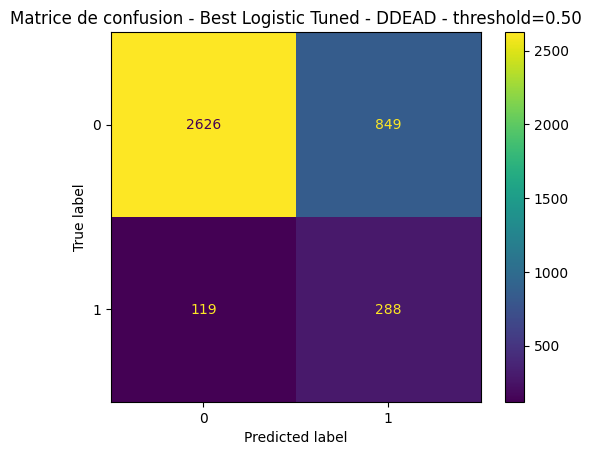

Target : FDEAD
Modèle : Best Logistic Tuned
Threshold : 0.50
Accuracy  : 0.7360
Precision : 0.4484
Recall    : 0.7151
F1-score  : 0.5511
AUC-ROC   : 0.7985

Classification Report :
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      2982
           1       0.45      0.72      0.55       874

    accuracy                           0.74      3856
   macro avg       0.67      0.73      0.68      3856
weighted avg       0.80      0.74      0.75      3856



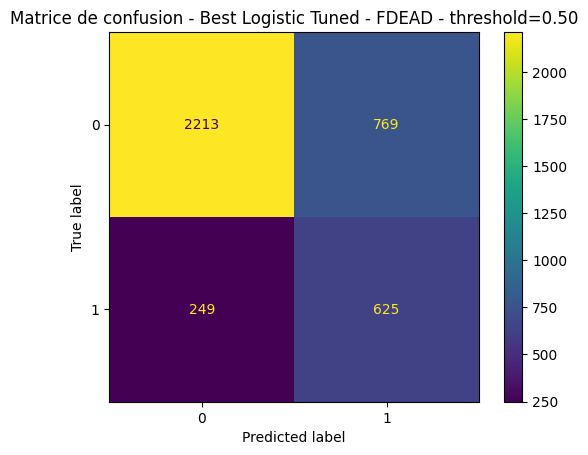

In [ ]:
# =========================
# 18. EVALUATION DES MEILLEURS MODELES TUNES
# =========================
best_model_ddead_tuned = grid_ddead.best_estimator_
best_model_fdead_tuned = grid_fdead.best_estimator_

best_default_ddead, _, _ = evaluate_at_threshold(
    model=best_model_ddead_tuned,
    X_test=X_test_ddead,
    y_test=y_test_ddead,
    threshold=0.5,
    target_name="DDEAD",
    model_name="Best Logistic Tuned"
)

best_default_fdead, _, _ = evaluate_at_threshold(
    model=best_model_fdead_tuned,
    X_test=X_test_fdead,
    y_test=y_test_fdead,
    threshold=0.5,
    target_name="FDEAD",
    model_name="Best Logistic Tuned"
)

In [ ]:
# =========================
# 19. THRESHOLD TUNING SUR MODELES TUNES
# =========================
best_threshold_ddead_tuned, threshold_results_ddead_tuned = find_best_threshold_by_recall(
    model=best_model_ddead_tuned, X_test=X_test_ddead, y_test=y_test_ddead
)

best_threshold_fdead_tuned, threshold_results_fdead_tuned = find_best_threshold_by_recall(
    model=best_model_fdead_tuned, X_test=X_test_fdead, y_test=y_test_fdead
)

print("Threshold tuned optimal détecté pour DDEAD :", round(float(best_threshold_ddead_tuned), 2))
print("Threshold tuned optimal détecté pour FDEAD :", round(float(best_threshold_fdead_tuned), 2))
print("Threshold final retenu pour DDEAD :", 0.20)
print("Threshold final retenu pour FDEAD :", 0.25)

print("
Résultats des seuils - Modèle tuné DDEAD")
display(threshold_results_ddead_tuned)

print("Résultats des seuils - Modèle tuné FDEAD")
display(threshold_results_fdead_tuned)


Threshold tuned retenu pour DDEAD : 0.2
Threshold tuned retenu pour FDEAD : 0.25


Target : DDEAD
Modèle : Best Logistic Tuned + Threshold
Threshold : 0.20
Accuracy  : 0.3815
Precision : 0.1398
Recall    : 0.9509
F1-score  : 0.2438
AUC-ROC   : 0.7921

Classification Report :
              precision    recall  f1-score   support

           0       0.98      0.31      0.48      3475
           1       0.14      0.95      0.24       407

    accuracy                           0.38      3882
   macro avg       0.56      0.63      0.36      3882
weighted avg       0.89      0.38      0.45      3882



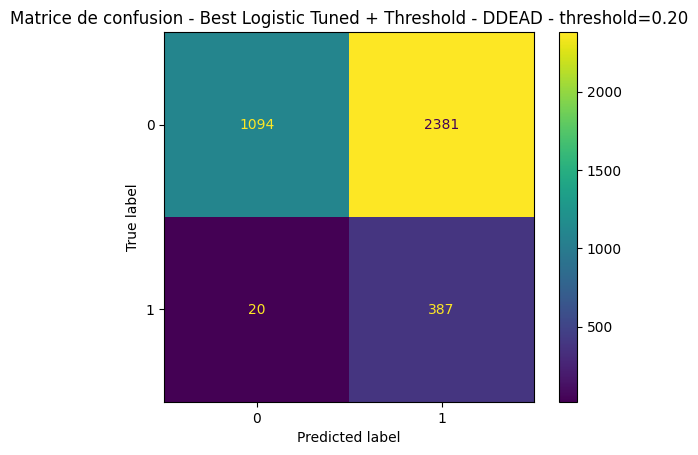

Target : FDEAD
Modèle : Best Logistic Tuned + Threshold
Threshold : 0.25
Accuracy  : 0.4780
Precision : 0.2951
Recall    : 0.9382
F1-score  : 0.4489
AUC-ROC   : 0.7985

Classification Report :
              precision    recall  f1-score   support

           0       0.95      0.34      0.50      2982
           1       0.30      0.94      0.45       874

    accuracy                           0.48      3856
   macro avg       0.62      0.64      0.48      3856
weighted avg       0.80      0.48      0.49      3856



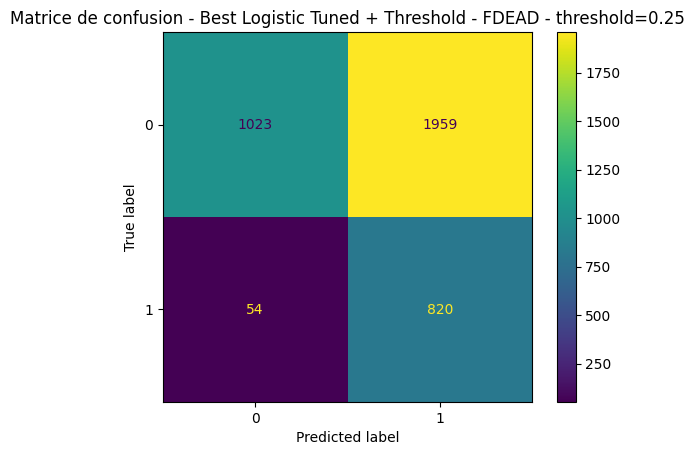

Comparaison finale - DDEAD


,Target,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,DDEAD,Logistic Regression V3,0.5,0.756569,0.258094,0.705160,0.377880,0.794262
1,DDEAD,Logistic Regression V3 Tuned,0.2,0.436373,0.148718,0.926290,0.256288,0.794262
2,DDEAD,Best Logistic Tuned,0.5,0.750644,0.253298,0.707617,0.373057,0.792109
3,DDEAD,Best Logistic Tuned + Threshold,0.2,0.381504,0.139812,0.950860,0.243780,0.792109


Comparaison finale - FDEAD


,Target,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,FDEAD,Logistic Regression V3,0.50,0.741701,0.455409,0.712815,0.555754,0.798841
1,FDEAD,Logistic Regression V3 Tuned,0.25,0.487811,0.299014,0.937071,0.453363,0.798841
2,FDEAD,Best Logistic Tuned,0.50,0.735996,0.448350,0.715103,0.551146,0.798509
3,FDEAD,Best Logistic Tuned + Threshold,0.25,0.477956,0.295070,0.938215,0.448946,0.798509


In [ ]:
# =========================
# 20. EVALUATION FINALE DES MODELES TUNES
# =========================
final_tuned_ddead, _, _ = evaluate_at_threshold(
    model=best_model_ddead_tuned,
    X_test=X_test_ddead,
    y_test=y_test_ddead,
    threshold=0.2,
    target_name="DDEAD",
    model_name="Best Logistic Tuned + Threshold"
)

final_tuned_fdead, _, _ = evaluate_at_threshold(
    model=best_model_fdead_tuned,
    X_test=X_test_fdead,
    y_test=y_test_fdead,
    threshold=0.25,
    target_name="FDEAD",
    model_name="Best Logistic Tuned + Threshold"
)

final_comparison_ddead = pd.DataFrame([
    baseline_ddead,
    tuned_ddead,
    best_default_ddead,
    final_tuned_ddead
])

final_comparison_fdead = pd.DataFrame([
    baseline_fdead,
    tuned_fdead,
    best_default_fdead,
    final_tuned_fdead
])

print("Comparaison finale - DDEAD")
display(final_comparison_ddead)

print("Comparaison finale - FDEAD")
display(final_comparison_fdead)

## Visualisation comparative des modèles et résultats finaux

Cette section regroupe les modèles évalués pour **DDEAD** et **FDEAD**, met en avant le **Recall** et présente un **tableau final synthétique** avec les seuils retenus (**0.20** et **0.25**).

In [ ]:
# =========================
# 21. VISUALISATION COMPARATIVE DES MODELES
# =========================

metric_cols = ["Accuracy", "Precision", "Recall", "F1-score", "AUC-ROC"]

comparison_ddead_vis = final_comparison_ddead.copy()
comparison_fdead_vis = final_comparison_fdead.copy()
comparison_ddead_vis["Target"] = "DDEAD"
comparison_fdead_vis["Target"] = "FDEAD"

global_comparison = pd.concat(
    [comparison_ddead_vis, comparison_fdead_vis],
    axis=0,
    ignore_index=True
)

# Ordre logique des modèles
model_order = [
    "Logistic Regression V3",
    "Logistic Regression V3 Tuned",
    "Best Logistic Tuned",
    "Best Logistic Tuned + Threshold"
]

global_comparison["Model"] = pd.Categorical(
    global_comparison["Model"], categories=model_order, ordered=True
)
global_comparison = global_comparison.sort_values(["Target", "Model"]).reset_index(drop=True)

for col in metric_cols + ["Threshold"]:
    if col in global_comparison.columns:
        global_comparison[col] = global_comparison[col].astype(float).round(4)

print("=== Comparaison globale des modèles ===")
display(global_comparison)

# -------------------------
# Visualisation du Recall
# -------------------------
for target in ["DDEAD", "FDEAD"]:
    df_target = global_comparison[global_comparison["Target"] == target].copy()

    plt.figure(figsize=(10, 5))
    bars = plt.bar(df_target["Model"].astype(str), df_target["Recall"])
    plt.title(f"Comparaison du Recall des modèles - {target}")
    plt.xlabel("Modèle")
    plt.ylabel("Recall")
    plt.ylim(0, 1.05)
    plt.xticks(rotation=20, ha="right")

    for bar, value in zip(bars, df_target["Recall"]):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{value:.3f}",
            ha="center"
        )

    plt.tight_layout()
    plt.show()

# -------------------------
# Visualisation complète des métriques finales
# -------------------------
for target in ["DDEAD", "FDEAD"]:
    df_target = global_comparison[global_comparison["Target"] == target].copy()
    plot_df = df_target.set_index("Model")[metric_cols]

    ax = plot_df.plot(kind="bar", figsize=(12, 6))
    plt.title(f"Comparaison des métriques des modèles - {target}")
    plt.xlabel("Modèle")
    plt.ylabel("Score")
    plt.ylim(0, 1.05)
    plt.xticks(rotation=20, ha="right")
    plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    plt.tight_layout()
    plt.show()

# -------------------------
# Tableau de synthèse final
# -------------------------
def build_final_summary(df_target, target_name, selected_threshold):
    best_recall_idx = df_target["Recall"].idxmax()
    best_recall_row = df_target.loc[best_recall_idx]

    final_row = df_target[df_target["Model"].astype(str) == "Best Logistic Tuned + Threshold"]
    if len(final_row) == 0:
        final_row = df_target.iloc[[-1]]
    else:
        final_row = final_row.iloc[[0]]

    final_row = final_row.copy()
    final_row["Selected Threshold"] = selected_threshold
    final_row["Best Recall Model"] = str(best_recall_row["Model"])
    final_row["Best Recall Value"] = round(float(best_recall_row["Recall"]), 4)
    final_row["Final Decision"] = "Modèle final retenu"
    return final_row

summary_ddead = build_final_summary(
    global_comparison[global_comparison["Target"] == "DDEAD"],
    target_name="DDEAD",
    selected_threshold=0.20
)
summary_fdead = build_final_summary(
    global_comparison[global_comparison["Target"] == "FDEAD"],
    target_name="FDEAD",
    selected_threshold=0.25
)

final_results_summary = pd.concat([summary_ddead, summary_fdead], ignore_index=True)

cols_summary = [
    "Target", "Model", "Threshold", "Selected Threshold",
    "Accuracy", "Precision", "Recall", "F1-score", "AUC-ROC",
    "Best Recall Model", "Best Recall Value", "Final Decision"
]
final_results_summary = final_results_summary[[col for col in cols_summary if col in final_results_summary.columns]]

print("=== Résultats finaux retenus ===")
display(final_results_summary)


In [ ]:
# =========================
# 21. SAUVEGARDE DES ARTEFACTS
# =========================
model_dir = "/content/drive/MyDrive/Stroke_Project_ML/Models/"
results_dir = "/content/drive/MyDrive/Stroke_Project_ML/Results/"

os.makedirs(model_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

# Sauvegarde des modèles
joblib.dump(model_ddead, model_dir + "logistic_ddead_v3_threshold_shap.pkl")
joblib.dump(model_fdead, model_dir + "logistic_fdead_v3_threshold_shap.pkl")

joblib.dump(best_model_ddead_tuned, model_dir + "logistic_ddead_v3_cv_grid_tuned.pkl")
joblib.dump(best_model_fdead_tuned, model_dir + "logistic_fdead_v3_cv_grid_tuned.pkl")

# Sauvegarde des résultats de threshold tuning
threshold_results_ddead.to_csv(results_dir + "threshold_results_ddead_v3.csv", index=False)
threshold_results_fdead.to_csv(results_dir + "threshold_results_fdead_v3.csv", index=False)
threshold_results_ddead_tuned.to_csv(results_dir + "threshold_results_ddead_v3_tuned.csv", index=False)
threshold_results_fdead_tuned.to_csv(results_dir + "threshold_results_fdead_v3_tuned.csv", index=False)

# Sauvegarde des tableaux comparatifs
comparison_ddead.to_csv(results_dir + "comparison_ddead_v3.csv", index=False)
comparison_fdead.to_csv(results_dir + "comparison_fdead_v3.csv", index=False)
final_comparison_ddead.to_csv(results_dir + "final_comparison_ddead_v3.csv", index=False)
final_comparison_fdead.to_csv(results_dir + "final_comparison_fdead_v3.csv", index=False)
global_comparison.to_csv(results_dir + "global_comparison_v3.csv", index=False)
final_results_summary.to_csv(results_dir + "final_results_summary_v3.csv", index=False)

# Sauvegarde des résultats SHAP
importance_ddead.to_csv(results_dir + "shap_importance_ddead_v3.csv", index=False)
importance_fdead.to_csv(results_dir + "shap_importance_fdead_v3.csv", index=False)

print("Artefacts V3 sauvegardés avec succès.")
print("Seuil final retenu DDEAD : 0.20")
print("Seuil final retenu FDEAD : 0.25")


Artefacts V3 sauvegardés avec succès.


## Conclusion

Cette version mise à jour du **Modeling V3** apporte quatre améliorations majeures :

### ✅ 1. Threshold tuning
Le seuil de décision n’est plus fixé arbitrairement à `0.5`.

### ✅ 2. Analyse SHAP
Le modèle devient plus interprétable et plus transparent.

### ✅ 3. Validation croisée
Les performances sont évaluées de manière plus robuste sur plusieurs folds.

### ✅ 4. Tuning des hyperparamètres
Le modèle est optimisé selon la métrique la plus pertinente pour le projet : le **Recall**.



**=> Le tuning des hyperparamètres améliore légèrement les performances, mais l’optimisation du seuil de décision est le facteur le plus déterminant pour augmenter le recall dans ce problème déséquilibré.**


### ✅ 5. Décision finale
Les seuils retenus pour l'interprétation finale et la comparaison visuelle sont **0.20 pour DDEAD** et **0.25 pour FDEAD**, car ils renforcent le **Recall**, métrique prioritaire du projet.
